<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/MACHINE-LEARNING-EXERCISES/blob/main/Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
data = pd.read_csv(url, sep=";")

print(data.head())
print(data.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

In [16]:
X = data.drop("quality", axis=1).values   # INPUT
y = data["quality"].values                # OUTPUT

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [20]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [21]:
class WineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)   # PREDICT

model = WineModel()

In [22]:
loss_function = nn.MSELoss()   # LOSS FUNCTION
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
epochs = 50
loss_history = []

for epoch in range(epochs):   # EPOCH
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:   # BATCH
        optimizer.zero_grad()

        y_pred = model(X_batch)            # PREDICT
        loss = loss_function(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/50 - Loss: 14.5550
Epoch 2/50 - Loss: 2.1063
Epoch 3/50 - Loss: 1.5578
Epoch 4/50 - Loss: 1.1993
Epoch 5/50 - Loss: 0.9538
Epoch 6/50 - Loss: 0.7562
Epoch 7/50 - Loss: 0.6409
Epoch 8/50 - Loss: 0.5750
Epoch 9/50 - Loss: 0.5500
Epoch 10/50 - Loss: 0.5339
Epoch 11/50 - Loss: 0.5197
Epoch 12/50 - Loss: 0.5137
Epoch 13/50 - Loss: 0.5046
Epoch 14/50 - Loss: 0.5047
Epoch 15/50 - Loss: 0.4944
Epoch 16/50 - Loss: 0.4951
Epoch 17/50 - Loss: 0.4888
Epoch 18/50 - Loss: 0.4872
Epoch 19/50 - Loss: 0.4791
Epoch 20/50 - Loss: 0.4805
Epoch 21/50 - Loss: 0.4703
Epoch 22/50 - Loss: 0.4738
Epoch 23/50 - Loss: 0.4687
Epoch 24/50 - Loss: 0.4758
Epoch 25/50 - Loss: 0.4662
Epoch 26/50 - Loss: 0.4646
Epoch 27/50 - Loss: 0.4638
Epoch 28/50 - Loss: 0.4623
Epoch 29/50 - Loss: 0.4574
Epoch 30/50 - Loss: 0.4537
Epoch 31/50 - Loss: 0.4513
Epoch 32/50 - Loss: 0.4569
Epoch 33/50 - Loss: 0.4403
Epoch 34/50 - Loss: 0.4447
Epoch 35/50 - Loss: 0.4456
Epoch 36/50 - Loss: 0.4343
Epoch 37/50 - Loss: 0.4374
Epoch 38/

In [24]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

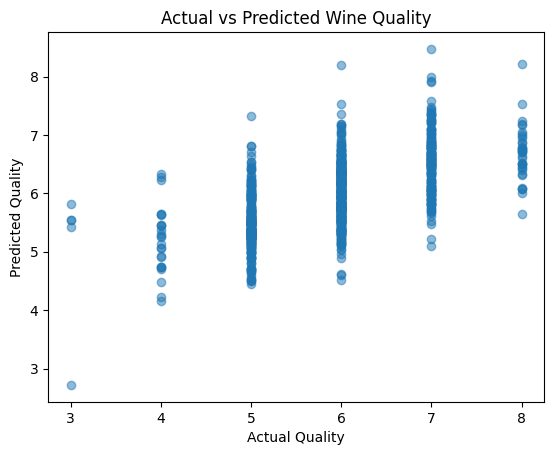

In [25]:
plt.figure()
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

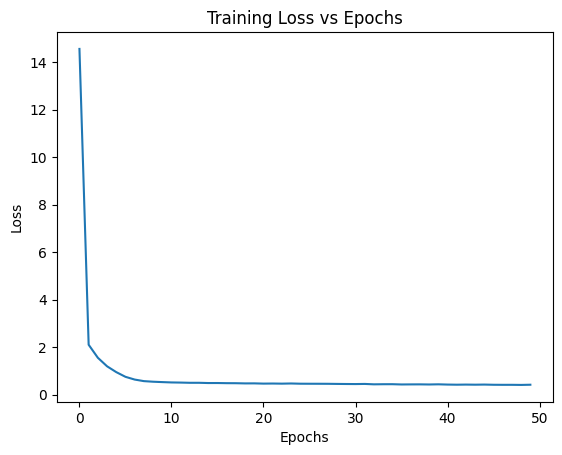

In [26]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()